In [157]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [232]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

def get_vals(T):
    '''
    Run the PyBaMM model and extract the current, voltage, and concentration
    '''
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(RNG=None);
    t = np.linspace(0, sol['Time [s]'].entries[-1], T)
    I = sol.observe(model.variables['Current [A]'])(t)
    V = sol.observe(model.variables['Terminal voltage [V]'])(t)
    cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
    cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.

    # print(param['Nominal cell capacity [A.h]'])
    # print(t[-1])
    return t, V, I, cn, cp

def gen_data_I_c(B, T):
    '''
    B: batch size, T: time steps
    '''
    V = np.zeros((B, T, 1)) # 1 channel
    I = np.zeros((B, T, 1))
    I_dot = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))

    for i in trange(B):
        t, V[i, :, 0], I[i, :, 0], cn[i, :, 0], cp[i, :, 0] = get_vals(T)
        # dt = t[1] - t[0]  # Assuming uniform time steps
        dt = 1  # Override dt to 1 step for simplicity --> cn_dot = cn_delta
        # cn_dot[i, 0, :] = np.gradient(cn[i, 0, :], dt)

        cn_dot[:, :-1] = np.diff(cn, axis=1)
        cp_dot[:, :-1] = np.diff(cp, axis=1)
        I_dot[:, 1:] = -np.diff(I, axis=1) # Backward difference, first time step is zero

        cn_dot[:, -1] = cn_dot[:, -2]  # Pad last time step with second to last value
        cp_dot[:, -1] = cp_dot[:, -2]  # Pad last time

    return I, V, cn, cn_dot, cp, cp_dot



In [234]:
B = 5000
T = 1000
I, V, cn, cn_dot, cp, cp_dot = gen_data_I_c(B, T)
np.savez('data_c_dot.npz', I=I, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot)

 84%|████████▎ | 4182/5000 [41:20<03:08,  4.33it/s]    2026-02-26 13:57:42.827 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 0.9151739055188997C for 1848 seconds'. The returned solution only contains up to step 1 of cycle 3. 
100%|██████████| 5000/5000 [44:20<00:00,  1.88it/s]


In [ ]:
data = np.load('data_c_dot.npz')

In [239]:
I = np.load('data_c_dot.npz')['I']
V = np.load('data_c_dot.npz')['V']
cn = np.load('data_c_dot.npz')['cn']
cn_dot = np.load('data_c_dot.npz')['cn_dot']
cp = np.load('data_c_dot.npz')['cp']
cp_dot = np.load('data_c_dot.npz')['cp_dot']


In [223]:

# Split batches
test_size = 0.1
split = int(test_size * B)

# Split and convert to float32 for PyTorch
I_test = I[:split].astype(np.float32)
I_train = I[split:].astype(np.float32)
I_dot_test = I_dot[:split].astype(np.float32)
I_dot_train = I_dot[split:].astype(np.float32)
cn_test = cn[:split].astype(np.float32)
cn_train = cn[split:].astype(np.float32)
cn_dot_test = cn_dot[:split].astype(np.float32)
cn_dot_train = cn_dot[split:].astype(np.float32)

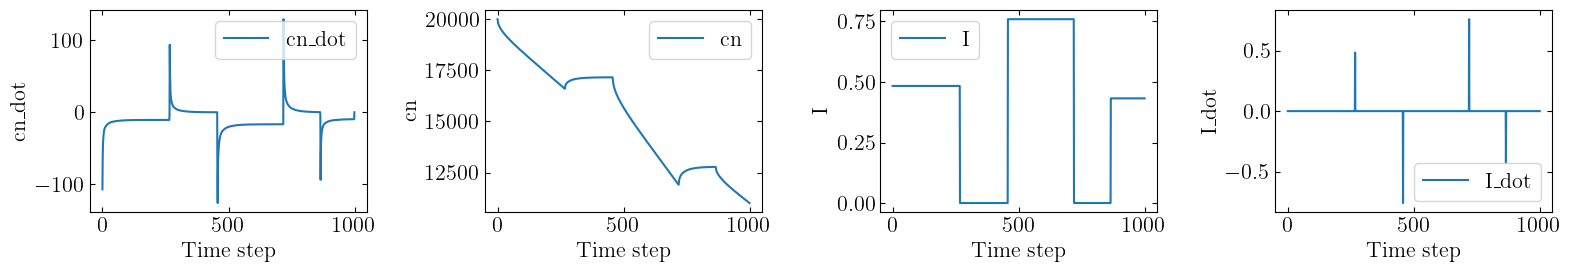

In [224]:
idb = 2

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot_train[idb, :, 0], label='cn_dot')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot')
ax1.legend()
ax2.plot(cn_train[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn')
ax2.legend()
ax3.plot(I_train[idb, :, 0], label='I')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I')
ax3.legend()
ax4.plot(I_dot_train[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot')
ax4.legend()
plt.tight_layout()

In [225]:
# -----------------------------
# 1) Scaling
# -----------------------------

# For physics/ODE models you usually want GLOBAL scaling, not a separate mean/std per time index.
scaler_I = StandardScaler()
scaler_I_dot = StandardScaler()
scaler_cn = StandardScaler()
scaler_cn_dot = StandardScaler()

def scale(data, scaler):
    B, T, C = data.shape
    data_flat = data.reshape(-1, C)  # (B*T, C)

    data_scaled_flat = scaler.fit_transform(data_flat)  # (B*T, C)
    return data_scaled_flat.reshape(B, T, C)  # (B, T, C)

I_train_s = scale(I_train, scaler_I)
I_test_s = scale(I_test, scaler_I)
I_dot_train_s = scale(I_dot_train, scaler_I_dot)
I_dot_test_s = scale(I_dot_test, scaler_I_dot)
cn_train_s = scale(cn_train, scaler_cn)
cn_test_s = scale(cn_test, scaler_cn)
cn_dot_train_s = scale(cn_dot_train, scaler_cn_dot)
cn_dot_test_s = scale(cn_dot_test, scaler_cn_dot)

train_dataset = TensorDataset(torch.from_numpy(I_train),    # Not using scaled
                              torch.from_numpy(I_dot_train), 
                              torch.from_numpy(cn_train_s), 
                              torch.from_numpy(cn_dot_train_s))
batch_size = int(B/3)
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


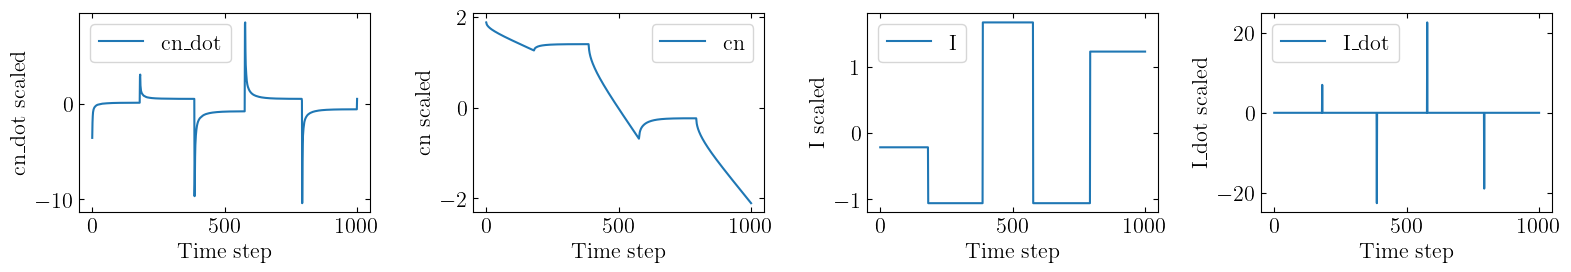

In [226]:
idb = 4

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot_train_s[idb, :, 0], label='cn_dot')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot scaled')
ax1.legend()
ax2.plot(cn_train_s[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn scaled')
ax2.legend()
ax3.plot(I_train_s[idb, :, 0], label='I')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I scaled')
ax3.legend()
ax4.plot(I_dot_train_s[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot scaled')
ax4.legend()
plt.tight_layout()

In [ ]:
# -----------------------------
# 2) Network
# -----------------------------

# class Net(nn.Module):
#     def __init__(self, hidden_dim=128):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(in_features=2, out_features=hidden_dim), # input i_k, c_k
#             nn.Tanh(),
#             nn.Linear(hidden_dim, hidden_dim),
#             nn.Tanh(),
#             nn.Linear(hidden_dim, 1)  # output c_dot_k
#         )

#     def forward(self, I, c):
#         # x: [B*T, 1], c: [B*T, 1]
#         x = torch.cat([I, c], dim=-1)  # [B*T, 2]
#         return self.net(x)
    
''' With I_dot as input '''
class Net(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=3, out_features=hidden_dim), # input i_t, i_dot_t, c_t
            nn.Tanh(),
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),  # output c_dot_k
        )

    def forward(self, I, I_dot, c):
        # x: [B*T, 1], c: [B*T, 1]
        x = torch.cat([I, I_dot, c], dim=-1)  # [B*T, 3]
        output = self.net(x)
        
        return output

In [228]:
# -----------------------------
# 3) Training loop
# -----------------------------

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

def training(epochs=50):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        last = None

        # for I_batch, cn_batch, cn_dot_batch in loader:
        #     # batch: (B, T, 1) -> (B*T, 1)
        #     I_flat = I_batch.reshape(-1, 1)
        #     cn_flat = cn_batch.reshape(-1, 1)
        #     y_flat = cn_dot_batch.reshape(-1, 1)

        ''' With I_dot '''
        for I_batch, I_dot_batch, cn_batch, cn_dot_batch in loader:
            # batch: (B, T, 1) -> (B*T, 1)
            I_flat = I_batch.reshape(-1, 1)
            I_dot_flat = I_dot_batch.reshape(-1, 1)
            cn_flat = cn_batch.reshape(-1, 1)
            y_flat = cn_dot_batch.reshape(-1, 1)
            
            # predict parameters
            cn_dot_hat = model(I_flat, I_dot_flat, cn_flat)

            loss = mse(cn_dot_hat, y_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            last = loss.item()

        history["loss"].append(last)

        print(f'Epoch {ep+1} | loss {last} |')

    return history

In [229]:
history = training(epochs=500)

Epoch 1 | loss 0.8550357818603516 |
Epoch 2 | loss 0.9133214950561523 |
Epoch 3 | loss 0.8238934874534607 |
Epoch 4 | loss 0.6497262716293335 |
Epoch 5 | loss 0.6107295155525208 |
Epoch 6 | loss 0.5457974672317505 |
Epoch 7 | loss 0.5680721402168274 |
Epoch 8 | loss 0.5096954107284546 |
Epoch 9 | loss 0.5424606204032898 |
Epoch 10 | loss 0.6050978899002075 |
Epoch 11 | loss 0.54301917552948 |
Epoch 12 | loss 0.5723289251327515 |
Epoch 13 | loss 0.49855485558509827 |
Epoch 14 | loss 0.5277973413467407 |
Epoch 15 | loss 0.5379025936126709 |
Epoch 16 | loss 0.5058600306510925 |
Epoch 17 | loss 0.5191847085952759 |
Epoch 18 | loss 0.5274205207824707 |
Epoch 19 | loss 0.5389733910560608 |
Epoch 20 | loss 0.5588364005088806 |
Epoch 21 | loss 0.5278651714324951 |
Epoch 22 | loss 0.5309558510780334 |
Epoch 23 | loss 0.5382603406906128 |
Epoch 24 | loss 0.5224500894546509 |
Epoch 25 | loss 0.5096678733825684 |
Epoch 26 | loss 0.4531981647014618 |
Epoch 27 | loss 0.5431820750236511 |
Epoch 28 | 

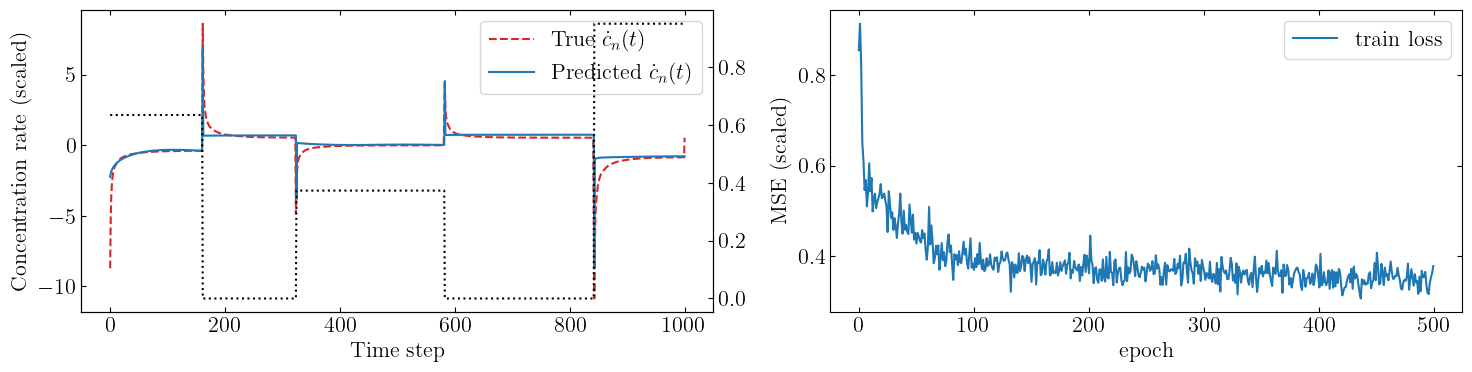

In [230]:
# -----------------------------
# 4) Test + plot
# -----------------------------
''' Predicted on known cn, not using Euler to step forward '''
model.eval()
idx = 2

cn_dot_hat_list = []

# for t in range(T):
#     I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
#     cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)

#     with torch.no_grad():
#         cn_dot_hat = model(I_t, cn_t).item()    # pick item from output tensor

#     cn_dot_hat_list.append(cn_dot_hat)


''' With I_dot as input '''
for t in range(T):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)

    with torch.no_grad():
        cn_dot_hat = model(I_t, I_dot_t, cn_t).item()    # pick item from output tensor

    cn_dot_hat_list.append(cn_dot_hat)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

ax1_ = ax1.twinx()

ax1.plot(cn_dot_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1_.plot(I_test[idx, :, 0], label='I', color='black', linestyle='dotted')
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(history["loss"], label="train loss")
ax2.set_xlabel("epoch")
ax2.set_ylabel("MSE (scaled)")
ax2.legend()

plt.tight_layout()

Initial cn: -1.2379


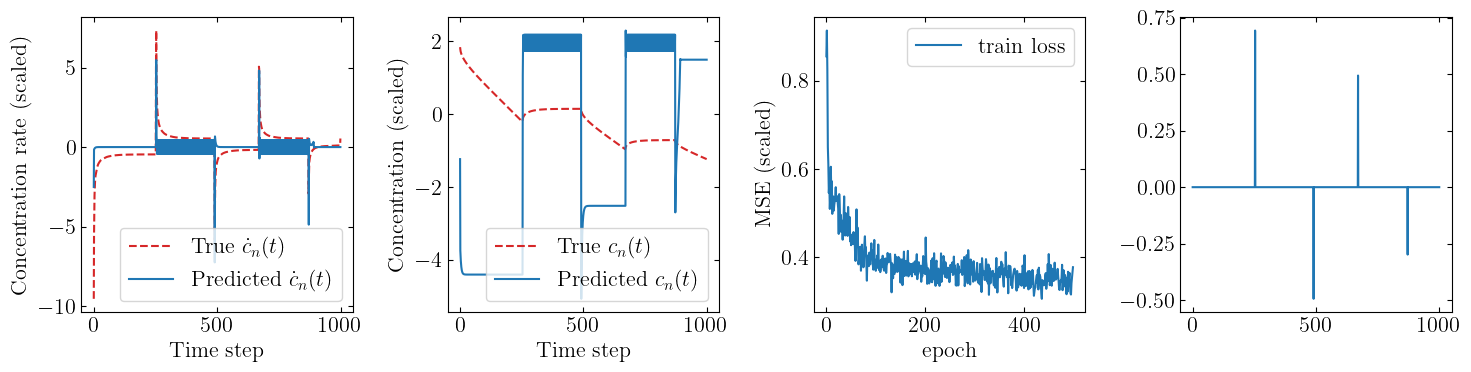

In [231]:
# -----------------------------
# 5) Predict from euler forward 
# -----------------------------
model.eval()
idx = 0

cn_euler = np.zeros_like(cn_test_s)  # (B, T, 1)
cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32).item()
cn_euler[idx, 0, 0] = cn_t
print(f"Initial cn: {cn_t:.4f}")

cn_dot_hat_list = []
# dt = t_tot / T  # Total time divided by number of steps, assuming uniform spacing
dt = 1


# def step(idx, t, I_t, cn_t):
#     # Predict cn_dot from current I_t and concentration cn_t
#     with torch.no_grad():
#             cn_dot_hat = model(I_t, cn_t).item()    # pick item from output tensor
#     # Euler step: c_{k+1} = c_k + c_dot_k * dt
#     cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat * dt
#     return cn_dot_hat


# for t in range(T):
#     I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)

#     if t == 0:
#         # Predict on initial concentration, then use Euler to step forward
#         cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)
#         cn_dot_hat = step(idx, t, I_t, cn_t)
#     elif t < T-1:
#         cn_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)  # (1,1)
#         cn_dot_hat = step(idx, t, I_t, cn_t)

#     cn_dot_hat_list.append(cn_dot_hat)
#     # print(f"True cn_dot: {cn_dot_test_s[idx, t, 0]:.4f} | Predicted cn_dot: {cn_dot_hat:.4f}")

''' With I_dot as input '''
def step(idx, t, I_t, I_dot, cn_t):
    # Predict cn_dot from current I_t and concentration cn_t
    with torch.no_grad():
            cn_dot_hat = model(I_t, I_dot, cn_t).item()    # pick item from output tensor
    # Euler step: c_{k+1} = c_k + c_dot_k * dt
    cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat * dt
    return cn_dot_hat


for t in range(T):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)

    if t == 0:
        # Predict on initial concentration, then use Euler to step forward
        cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t)
    elif t < T-1:
        cn_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t)

    cn_dot_hat_list.append(cn_dot_hat)
    # print(f"True cn_dot: {cn_dot_test_s[idx, t, 0]:.4f} | Predicted cn_dot: {cn_dot_hat:.4f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4))

ax1.plot(cn_dot_test_s[idx, :, 0],  color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(history["loss"], label="train loss")
ax3.set_xlabel("epoch")
ax3.set_ylabel("MSE (scaled)")
ax3.legend()

ax4.plot(I_dot_test[idx, :, 0], label='I_dot', color='tab:blue')
plt.tight_layout()
# plt.savefig('figs/2_JN_PENN_ECM.pdf')